In [5]:
# Test with a fake tree

import polars as pl
from core import *

germline_sequence = "ATGCCGTAATGCCGTAATGCCGTA"*20

all_sequences = [germline_sequence]
for ii in range(200):
    new_sequence = all_sequences[-1]
    all_sequences += [new_sequence[:ii] + 'T' + new_sequence[ii+1:]]
    all_sequences += [new_sequence[:ii] + 'C' + new_sequence[ii+1:]]
    
df = pl.DataFrame(
    {'sequence_alignment': all_sequences,
     'germline_alignment': [germline_sequence[:-5] + 'AAAAA' for a in all_sequences],
     'sequence_id' : [f'Leaf{ii}' for ii, _ in enumerate(all_sequences)],
     'group_id': ['Clonal' for _ in all_sequences]}
)

# test
df = infer_trees(df, n_subsample=50)
tree = extract_trees(df)['Clonal']

100%|███████████████████████████████████████████████████████████| 1/1 [00:17<00:00, 17.41s/it]


In [6]:
## Test with real sequences

import polars as pl
from core import *


df = pl.read_csv('../example_airr.csv')
df = df.rename({'cdr1fwr3_sequence_alignment': 'sequence_alignment', 
                'cdr1fwr3_germline_alignment': 'germline_alignment', 
                'clonal_family_hilary': 'group_id'})

df = infer_trees(df, n_subsample=50)
trees = extract_trees(df)

100%|█████████████████████████████████████████████████████████| 10/10 [01:36<00:00,  9.61s/it]


In [11]:
trees['736578.Alief'].show()

AttributeError: 'ete4.core.tree.Tree' object has no attribute '_img_style'

AttributeError: 'ete4.core.tree.Tree' object has no attribute '_img_style'

AttributeError: 'ete4.core.tree.Tree' object has no attribute '_img_style'

In [10]:
trees

{'26317.Alief': <Tree '73625004c1f94218a72175cbbe830152_Node0' at 0x71ff245d329>,
 '736578.Alief': <Tree '0855719081ba4fc78a5cd3962c46f35c_Node0' at 0x71ff2356aed>,
 '1103465.Alief': <Tree '2486494737114ddba89b72f027d9d591_Node0' at 0x71ff235a20c>,
 '2188147.Alief': <Tree '54de6f429ba249d2b7434e83dfa70e9d_Node0' at 0x71ff2358d8f>,
 '751503.Alief': <Tree '2f9f6833e70a45748c2632f107b2c84a_Node0' at 0x71ff2450521>,
 '751534.Alief': <Tree '8adc747d4b6340fea0e34621b267d8f5_Node0' at 0x71ff2455a34>,
 '610184.Alief': <Tree 'eb79e03d181d4df4870fd2dd2e876ed9_Node0' at 0x71ff2353e61>,
 '2444605.Alief': <Tree 'f0d5aa052db0445e87b5b072bbe17472_Node0' at 0x71ff235a652>,
 '800584.Alief': <Tree 'f9e1705f3c6647839de41a65b3584bf2_Node0' at 0x71ff245c41d>,
 '801194.Alief': <Tree '39e1a888c9694fc5b0b17cbd65f44841_Node0' at 0x71ff245c7b5>}

100%|█████████████████████████████████████████████████████████| 10/10 [01:11<00:00,  7.18s/it]


sequence_id,germline_alignment,isotype,sequence_alignment,group_id,sequence_alignment_tree,ancestor_id,likelihood,likelihood_weight_ratio,distal_length,pendant_length,in_tree,germline_alignment_tree,mrca_alignment_tree,parent_sequence,mutations_from_nearest,mutations_from_germline,mutations_from_mrca,nb_mutations_from_mrca,nb_mutations_from_nearest,nb_mutations_from_germline,tree
str,str,str,str,str,str,str,f64,f64,f64,f64,bool,str,str,str,str,str,str,i64,i64,i64,str
"""BLOD_TD1_2_A12.clone.41678-igh""","""GGATTCACCTTTAGCAGCTATGCCATGAGC…","""IgG""","""GGATTCACCTTTAGCAGCTATGCCATGAGC…","""800584.Alief""","""-GGATTCACCTTTAGCAGCTATGCCATGAG…","""Node4""",-1114.459847,0.823254,0.015254,0.029466,false,"""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""I1G,I2G,I3A,I4T,I5T,I6C,SA118G…","""I1G,I2G,I3A,I4T,I5T,I6C,SA118G…","""I1G,I2G,I3A,I4T,I5T,I6C,SA118G…",20,20,20,"""((germline:5e-07[&&NHX:sequenc…"
"""BLOD_AM2_1_A13.clone.56172-igh""","""GGATTCACCTTTAGCAGCTATGCCATGAGC…","""IgG""","""GGATTCACCTTTAGCAGCTATGCCATGAGC…","""800584.Alief""","""-GGATTCACCTTTAGCAGCTATGCCATGAG…","""Node4""",-1097.373474,0.896583,0.015405,0.007489,false,"""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""I1G,I2G,I3A,I4T,I5T,I6C,SA145G…","""I1G,I2G,I3A,I4T,I5T,I6C,SA145G…","""I1G,I2G,I3A,I4T,I5T,I6C,SA145G…",16,16,16,"""((germline:5e-07[&&NHX:sequenc…"
"""BLOD_AM4_1_A9.clone.20662-igh""","""GGATTCACCTTTAGCAGCTATGCCATGAGC…","""IgD""","""GGATTCACCTTTAGAAGTTATGTCATGAGC…","""800584.Alief""","""-GGATTCACCTTTAGAAGTTATGTCATGAG…","""Node4""",-1134.124268,0.648601,0.0525,0.061572,false,"""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""I1G,I2G,I3A,I4T,I5T,I6C,SC15A,…","""I1G,I2G,I3A,I4T,I5T,I6C,SC15A,…","""I1G,I2G,I3A,I4T,I5T,I6C,SC15A,…",25,25,25,"""((germline:5e-07[&&NHX:sequenc…"
"""BLOD_AM4_1_A16.clone.63395-igh""","""GGATTCACCTTTAGCAGCTATGCCATGAGC…","""IgG""","""GGATTCACCTTTAGCAGCTATGCCATGAGC…","""800584.Alief""","""-GGATTCACCTTTAGCAGCTATGCCATGAG…","""Node2""",-1092.540661,0.548047,0.001935,0.009564,false,"""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""I1G,I2G,I3A,I4T,I5T,I6C,SG202T…","""I1G,I2G,I3A,I4T,I5T,I6C,SG202T…","""I1G,I2G,I3A,I4T,I5T,I6C,SG202T…",14,14,14,"""((germline:5e-07[&&NHX:sequenc…"
"""BLOD_TD1_2_A12.clone.2232-igh""","""ACCTTTAGCAGCTATGCCATGAGCTGGGTC…","""IgG""","""ATCTTTAGCAACTATGCCATGACCTGGGTC…","""800584.Alief""","""-------ATCTTTAGCAACTATGCCATGAC…","""Node15""",-1120.211317,0.999372,0.020463,0.0001,false,"""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""-------ACCTTTAGCAGCTATGCCATGAG…","""SC8T,SG17A,SG29C,SA76G,ST81A,S…","""SC8T,SG17A,SG29C,SG73A,SA76G,S…","""SC8T,SG17A,SG29C,SG73A,SA76G,S…",20,14,20,"""((germline:5e-07[&&NHX:sequenc…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""BLOD_AM7_2_A14.clone.7703-igh""","""TCCATCAGCAGTGGTAGTTACTACTGGAGC…","""IgG""","""TCCGTCGGTGCTGTTAGTTACTACTGGAGC…","""2444605.Alief""","""------TCCGTCGGTGCTGTTAGTTACTAC…","""Node8""",-1175.454651,1.0,0.00005,0.0001,false,"""------TCCATCAGCAGTGGTAGTTACTAC…","""------TCCATCAGCAGTGGTAGTTACTAC…","""------TCCATCAGTAGTGTTAGTTACTAC…","""SA9G,SA12G,SA15G,SG16C,SA39G,S…","""SA9G,SA12G,SC14T,SA15G,SG16C,S…","""SA9G,SA12G,SC14T,SA15G,SG16C,S…",23,13,25,"""((germline:0.01261[&&NHX:seque…"
"""BLOD_AM4_1_A16.clone.3413-igh""","""GGTGGCTCCATCAGCAGTGGTAGTTACTAC…","""IgA""","""GGCGCCTCCGTCAGCACTGTTAGTTACTAC…","""2444605.Alief""","""GGCGCCTCCGTCAGCACTGTTAGTTACTAC…","""Node17""",-1186.066386,1.0,0.00005,0.0001,true,"""------TCCATCAGCAGTGGTAGTTACTAC…","""------TCCATCAGCAGTGGTAGTTACTAC…","""------TCCATCAGCACTGTTAGTTACTAC…","""I0G,I1G,I2C,I3G,I4C,I5C,SA9G,S…","""I0G,I1G,I2C,I3G,I4C,I5C,SA9G,S…","""I0G,I1G,I2C,I3G,I4C,I5C,SA9G,S…",31,22,33,"""((germline:0.01261[&&NHX:seque…"
"""BLOD_AM2_1_A13.clone.1622-igh""","""TCCATCAGCAGTGGT

In [7]:
import ete4
t = ete4.Tree(df['tree'].sample().to_list()[0])

In [8]:
t.show()

/tmp/ipykernel_243682/3938449346.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['nb_mutations_from_germline'])


<Axes: xlabel='nb_mutations_from_germline', ylabel='Density'>

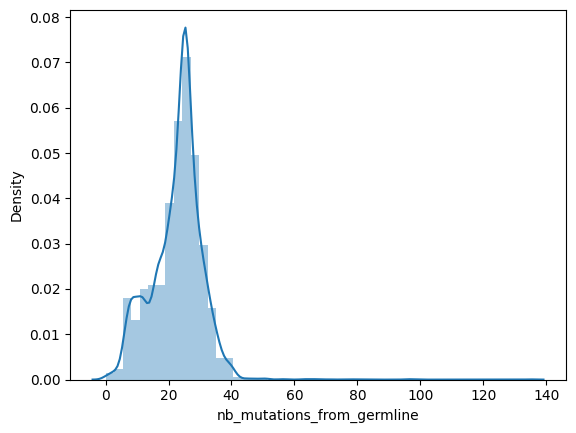

In [9]:
import seaborn as sns
sns.distplot(df['nb_mutations_from_germline'])

In [18]:
def collapse_placement(jplace_file, collapsed_tree_file):
    """
    Maps placement data from a jplace file onto a simplified (collapsed) tree using edge numbers,
    assigns each placement to the nearest internal node in the collapsed tree (via MRCA),
    and aggregates placement likelihoods per internal node.

    Parameters:
        jplace_file (str): Path to the .jplace file with sequence placements.
        collapsed_tree_file (str): Path to the Newick tree file used to group placements.

    Returns:
        pl.DataFrame: One row per query sequence, including:
            - best matching ancestor_id (collapsed tree node),
            - summed placement likelihoods,
            - average placement distances,
            - sequence ID.
    """
        
    with open(jplace_file) as f:
        jplace_data = json.load(f)

    tree_jplace = parse_jplace_tree(jplace_data['tree'])
    tree_collapse = ete4.Tree(collapsed_tree_file)
    for node in tree_collapse:
        if node.is_leaf:
            continue
        node.add_prop("edge_numbers", [])
    
    # identify ancestor of a given edge in the collapsed tree
    mapping_edges = {}
    for node in tree_jplace.traverse():
        if "edge_number" not in node.props:
            continue
        if node.is_leaf:
            node_collapse = list(tree_collapse.search_leaves_by_name(node.name))[0]
            mapping_edges[int(node.props["edge_number"])] = node_collapse.up.name
        else:
            # if not a leave, then it has at least 2 descendant leaves
            # both trees have the same label names 
            leaves_list = [list(tree_collapse.search_leaves_by_name(l.name))[0] for l in node]
            common_ancestor = tree_collapse.common_ancestor(leaves_list)
            mapping_edges[int(node.props["edge_number"])] = common_ancestor.up.name
        
    placements = jplace_data['placements']
    print(mapping_edges)
    # group the placement data
    all_placements = None
    for dct in placements:
        name = dct['n'][0]
        # don't add the germline sequence
        if name == 'germline':
            continue

        df_placement = pl.DataFrame(dct['p'],
                                     schema=['edge_number', 'likelihood',
                                             'likelihood_weight_ratio',
                                             'distal_length', 'pendant_length'],
                                    orient="row"
                                     )\
                         .with_columns(
                             ancestor_id =
                             pl.col('edge_number').replace_strict(mapping_edges)
                         )

        df_placement = df_placement.group_by('ancestor_id').agg(
            pl.col('likelihood').map_elements(lambda g: np.logaddexp.reduce(list(g)),
                                              return_dtype=float),
            pl.col('likelihood_weight_ratio').sum(),
            pl.col('distal_length').mean(),
            pl.col('pendant_length').mean()
        ).sort(by='likelihood_weight_ratio', descending=True
               ).with_columns(sequence_id = pl.lit(name)).head(1)

        all_placements = df_placement if all_placements is None else pl.concat([all_placements, df_placement]) 
        
    return all_placements

In [19]:
    out_directory = 'tmpcsw_80p9'
    
    full_alignment_file = os.path.join(out_directory, "clonal_alignment.fa")
    reduced_alignment_file = os.path.join(out_directory, "clonal_alignment_reduced.fa")
    # here we need to use "bestTree" rather than "bestTreeCollapsed" sadly
    reduced_tree_file = os.path.join(out_directory, "tree.raxml.bestTree")
    model_file = os.path.join(out_directory, "tree.raxml.bestModel")
    command = (f"{epang} --redo --ref-msa {reduced_alignment_file}"
           f" --tree {reduced_tree_file}"
           f" --query {full_alignment_file}  --outdir {out_directory}"
           f" --model {model_file}")

    result = subprocess.run(command,
                            stdout=subprocess.PIPE,
                            stderr=subprocess.PIPE,
                            shell=True)

    # load and correct the placement file
    jplace_file = os.path.join(out_directory, "epa_result.jplace")
    collapsed_tree_file = os.path.join(out_directory, "tree.raxml.bestTreeCollapsed.asr")
    df_placement = collapse_placement(jplace_file, collapsed_tree_file)
    tree_collapse = ete4.Tree(collapsed_tree_file)
    newick_str = tree_collapse.write(props=['name', 'sequence', 'edge_number'])
    asr_sequences = {n.name: n.props['sequence'] for n in tree_collapse.traverse() if n.name is not None}

    # merge with the alignment info 
    df_alignment = read_fasta(full_alignment_file)
    df_alignment = df_alignment.rename({'name': 'sequence_id',
                                        'sequence': 'sequence_alignment_tree'})
    df = df.join(df_alignment, on='sequence_id')
    df = df.join(df_placement, on='sequence_id')
    kept_names = read_fasta(reduced_alignment_file)['name'].to_list()
    df = df.with_columns(in_tree = pl.col('sequence_id').is_in(kept_names))

    # identify the mrca
    mrca_sequence = tree_collapse.common_ancestor(
        [l for l in tree_collapse if l.name != 'germline']).props['sequence']
    print(mrca_sequence)
    
    germline_sequence = df_alignment.filter(
        pl.col('sequence_id') == 'germline')['sequence_alignment_tree'][0]

    # identify the mutations
    df = df.with_columns(
        germline_alignment_tree = pl.lit(germline_sequence),
        mrca_alignment_tree = pl.lit(mrca_sequence),
        parent_sequence = pl.col('ancestor_id').replace_strict(asr_sequences)
    )
    df = df.with_columns(
        pl.struct(['sequence_alignment_tree', 'parent_sequence']).map_elements(
                      lambda r:
            mutation_string(r['parent_sequence'],
                            r['sequence_alignment_tree']
                            )
        , return_dtype=str).alias('mutations_from_nearest'),
        pl.struct(['sequence_alignment_tree', 'germline_alignment_tree']).map_elements(
                      lambda r:
            mutation_string(r['germline_alignment_tree'],
                            r['sequence_alignment_tree']
                            )
       , return_dtype=str ).alias('mutations_from_germline'),
        pl.struct(['sequence_alignment_tree', 'mrca_alignment_tree']).map_elements(        
                      lambda r:
            mutation_string(r['mrca_alignment_tree'],
                            r['sequence_alignment_tree']
                            )
        , return_dtype=str).alias('mutations_from_mrca')
    ).with_columns(
        pl.col('mutations_from_mrca').map_elements(lambda x:
                                                   count_mutations(x),
                                                   return_dtype=int
                                                   ).alias('nb_mutations_from_mrca'),
        pl.col('mutations_from_nearest').map_elements(lambda x:
                                                      count_mutations(x),
                                                      return_dtype=int
                                                      ).alias('nb_mutations_from_nearest'),
        pl.col('mutations_from_germline').map_elements(lambda x:
                                                       count_mutations(x),
                                                       return_dtype=int
                                                       ).alias('nb_mutations_from_germline'),
        # and add the tree
        pl.lit(newick_str).alias('tree')
    )


{36: None, 37: None, 34: 'Node2', 35: 'Node2', 32: 'Node3', 33: 'Node3', 26: 'Node5', 31: 'Node5', 2: 'Node7', 25: 'Node7', 29: 'Node5', 30: 'Node8', 0: 'Node9', 1: 'Node9', 3: 'Node10', 24: 'Node7', 27: 'Node8', 28: 'Node8', 20: 'Node7', 23: 'Node7', 18: 'Node10', 19: 'Node10', 21: 'Node10', 22: 'Node10', 4: 'Node17', 17: 'Node10', 15: 'Node17', 16: 'Node17', 5: 'Node22', 14: 'Node22', 6: 'Node25', 13: 'Node25', 7: 'Node27', 12: 'Node27', 10: 'Node27', 11: 'Node29', 8: 'Node29', 9: 'Node29'}
GGATTCACCTTCAGTAGCTATAGCA-TGAACTGGGTCCGCCAGGCTCCAGGGAA-GGGGCTGGAGTGGGTCTCATCCATTAGTAGTAGTAGTAGTTACATATACTACGCAGACTCTGTGAAGGGCCGATTCACCATCTCCAGAGACAACGCCAAGAACTCACTGTATCTGCA-AATGAACAGCCTGAGAGCCGAGGACACGG-CTGTGTATTACTGT


ComputeError: TypeError: object of type 'NoneType' has no len()

In [22]:
t = ete4.Tree(collapsed_tree_file)
for a in t.traverse():
    print(a.name)

None
germline
Node2
Node3
BLOD_TD2_2_A5.clone.12015-igh
Node5
BLOD_TD2_2_A5.clone.127578-igh
Node7
Node8
Node9
Node10
BLOD_TD2_2_A5.clone.550-igh
BLOD_TD2_2_A5.clone.58033-igh
BLOD_AM4_2_A6.clone.53053-igh
BLOD_AM4_1_A6.clone.79920-igh
BLOD_TD2_1_A5.clone.57844-igh
BLOD_TD2_2_A5.clone.80683-igh
Node17
BLOD_AM4_2_A6.clone.92877-igh
BLOD_TD2_2_A5.clone.5178-igh
BLOD_AM7_2_A4.clone.47078-igh
BLOD_AM2_1_A3.clone.21640-igh
Node22
BLOD_TD2_1_A5.clone.34904-igh
BLOD_AM4_1_A6.clone.12972-igh
Node25
BLOD_AM4_1_A6.clone.35665-igh
Node27
BLOD_TD2_2_A5.clone.75576-igh
Node29
BLOD_AM7_2_A4.clone.56705-igh
BLOD_TD1_2_A2.clone.26790-igh
BLOD_AM7_2_A4.clone.24649-igh


In [17]:
df.filter(pl.col('parent_sequence').is_null())

sequence_id,germline_alignment,isotype,sequence_alignment,group_id,sequence_alignment_tree,ancestor_id,likelihood,likelihood_weight_ratio,distal_length,pendant_length,in_tree,germline_alignment_tree,mrca_alignment_tree,parent_sequence
str,str,str,str,str,str,str,f64,f64,f64,f64,bool,str,str,str
"""BLOD_TD2_1_A5.clone.89874-igh""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""IgA""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""610184.Alief""","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null,-824.41885,0.992215,0.004832,0.0001,false,"""GGATTCACCTTCAGTAGCTATAGCA-TGAA…","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null
"""BLOD_TD2_1_A5.clone.114480-igh""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""IgG""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""610184.Alief""","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null,-835.644248,0.951126,0.004825,0.009898,false,"""GGATTCACCTTCAGTAGCTATAGCA-TGAA…","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null
"""BLOD_TD2_2_A5.clone.111855-igh""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""IgA""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""610184.Alief""","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null,-824.41885,0.992215,0.004832,0.0001,false,"""GGATTCACCTTCAGTAGCTATAGCA-TGAA…","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null
"""BLOD_TD2_1_A5.clone.105363-igh""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""IgA""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""610184.Alief""","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null,-824.41885,0.992215,0.004832,0.0001,false,"""GGATTCACCTTCAGTAGCTATAGCA-TGAA…","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null
"""BLOD_TD2_1_A5.clone.126973-igh""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""IgM""","""GGATTCACCTTCAGTAGCTATAGCATGAAC…","""610184.Alief""","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null,-824.427258,0.975076,0.004826,0.0001,false,"""GGATTCACCTTCAGTAGCTATAGCA-TGAA…","""GGATTCACCTTCAGTAGCTATAGCA-TGAA…",null


In [8]:
df = df.filter(pl.col('sequence_id') == "BLOD_TD1_2_A2.clone.2120-igh")

In [16]:
for a, b in zip(df['sequence_alignment'][0], consensus):
    if a != b:
        print(a, b)

T C
T A
T C
A G
C G
T C
G A
T G


In [20]:
a = "ggtgactccattagcagtagttattactggagttgggtccgccagcccccagggaaggggctggagtggattggggaaatctttcatagtggggacaccaactacaacccgtccctcaagagtcgagtcaccatatcagcaga-caagtccaagaaccagttctccctgaagctgaactct-gtgaccgccgcggacacggccgtttattactgt------------"
b = "ggtgactccattagcagtagttattactggagttgggtccgccagcccccagggaaggggctggagtggattggggaaatctttcatagtggggacaccaactacaacccgtccctcaagagtcgagtcaccatatcagcaga-caagtccaagaaccagttctccctgaagctgaactct-gtgaccgccgcggacacggccgtttattactgt------------"
b == a
c = "---ggtgactccattagcagtagttattactggagttgggtccgccagcccccagggaaggggctggagtggattggggaaatctttcatagtggggacaccaactacaacccgtccctcaagagtcgagtcaccatatcagcaga-caagtccaagaaccagttctccctgaagctgaactct-gtgaccgccgcggacacggccgtttattactgt------------"
b == c

False

In [7]:
def parse_jplace_tree(newick_str):
    """ Default ete doesn't like the jplace format. """
    newick_str = re.sub(r"\{(\d+)\}", r"[&&NHX:edge_number=\1]", newick_str)
    return ete4.Tree(newick_str)


with open('tmpq83hgic1/epa_result.jplace') as f:
    jplace_data = json.load(f)


t = parse_jplace_tree(jplace_data['tree'])

In [8]:
for n in t:
    print(n.props)

{'name': 'BLOD_TD1_2_A2.clone.2120-igh', 'dist': 1e-06, 'edge_number': '0'}
{'name': 'BLOD_AM2_1_A3.clone.32510-igh', 'dist': 0.105798, 'edge_number': '1'}
{'name': 'BLOD_AM4_2_A16.clone.29157-igh', 'dist': 0.071426, 'edge_number': '2'}
{'name': 'BLOD_AM2_2_A3.clone.18705-igh', 'dist': 0.043587, 'edge_number': '4'}
{'name': 'BLOD_AM4_1_A16.clone.14555-igh', 'dist': 0.075402, 'edge_number': '5'}
{'name': 'BLOD_AM1_2_A1.clone.52283-igh', 'dist': 0.049549, 'edge_number': '7'}
{'name': 'BLOD_AM4_1_A6.clone.28983-igh', 'dist': 0.094148, 'edge_number': '8'}
{'name': 'BLOD_TD2_2_A5.clone.92703-igh', 'dist': 0.162478, 'edge_number': '10'}
{'name': 'BLOD_AM2_1_A3.clone.17513-igh', 'dist': 0.030896, 'edge_number': '12'}
{'name': 'BLOD_AM7_1_A14.clone.2671-igh', 'dist': 0.046819, 'edge_number': '15'}
{'name': 'BLOD_AM4_2_A16.clone.70499-igh', 'dist': 0.063186, 'edge_number': '16'}
{'name': 'BLOD_AM4_1_A16.clone.25358-igh', 'dist': 0.059337, 'edge_number': '18'}
{'name': 'BLOD_AM4_1_A7.clone.45183

In [26]:
list(t.search_leaves_by_name(next(t.leaves()).name))

[<Tree 'BLOD_TD1_2_A2.clone.2120-igh' at 0x74a4d8b7459>]

In [15]:
a = next(t.leaves())

In [19]:
a.name

'BLOD_TD1_2_A2.clone.2120-igh'

In [21]:
t&"BLOD_TD1_2_A2.clone.2120-igh"

TypeError: unsupported operand type(s) for &: 'ete4.core.tree.Tree' and 'str'

In [31]:
for a in t.traverse():
    print(a.name)

None
germline
Node2
BLOD_TD1_2_A2.clone.2120-igh
Node4
Node5
Node6
Node7
BLOD_TD3_1_A10.clone.3358-igh
BLOD_TD1_2_A2.clone.31064-igh
BLOD_AM4_1_A6.clone.47211-igh
Node11
Node12
BLOD_AM2_1_A3.clone.32510-igh
BLOD_AM4_2_A16.clone.29157-igh
Node15
Node16
Node17
Node18
Node19
BLOD_TD1_2_A12.clone.56019-igh
BLOD_AM2_2_A3.clone.18705-igh
BLOD_AM4_1_A16.clone.14555-igh
Node23
BLOD_AM2_1_A3.clone.17513-igh
BLOD_AM7_1_A14.clone.2671-igh
BLOD_AM4_2_A16.clone.70499-igh
Node27
Node28
BLOD_TD2_2_A5.clone.92703-igh
BLOD_AM4_1_A16.clone.25358-igh
Node31
BLOD_AM1_2_A1.clone.52283-igh
BLOD_AM4_1_A6.clone.28983-igh
BLOD_AM4_1_A7.clone.45183-igh
Node35
BLOD_AM1_2_A1.clone.8682-igh
BLOD_AM4_2_A6.clone.42445-igh


In [8]:
ls /home/dupic/Downloads/

Cloud/    Documents/  Music/     Public/  Templates/  VMs/      Zotero/
Desktop/  Downloads/  Pictures/  snap/    Videos/     Windows/


In [22]:
import json
import re

def parse_jplace_tree(newick_str):
    """ This is a huge pain, ete doesn't like Matsen jplace format. So I need to fix it and read it myself """
    newick_str = re.sub(r"\{(\d+)\}", r"[&&NHX:edge_number=\1]", newick_str)
    return ete4.Tree(newick_str)



with open(os.path.join("tmps7haffnq", "epa_result.jplace")) as f:
      jplace_data = json.load(f)
tree = parse_jplace_tree(jplace_data['tree'])
jplace_data = jplace_data['placements']




In [34]:
def mutation_string(ref: str, alt: str) -> str:
    """
    ref, alt: aligned sequences of equal length (with '-' for gaps)
    Returns comma‑separated mutations of form (MIXCR style):
      S[from]pos[to]  (substitution)
      D[from]pos      (deletion)
      Ipos[to]        (insertion)
    Positions are zero‑based, for insertions the pos is where the inserted
    nucleotide sits in the final (inserted) sequence. 
    """
    assert len(ref) == len(alt), "Aligned sequences must be same length"
    muts = []
    for i, (r, a) in enumerate(zip(ref, alt)):
        if r == a:
            continue
        if r != "-" and a != "-":
            muts.append(f"S{r}{i}{a}")
        elif r != "-" and a == "-":
            muts.append(f"D{r}{i}")
        else:
            muts.append(f"I{i}{a}")
    return ",".join(muts)

mutation_string( 'A-G-CAAC','AAAACAAC')

'I1A,SG2A,I3A'

In [15]:
t = ete4.Tree('tmpr8vjkv5t/tree.raxml.bestTreeCollapsed')

In [22]:
for a in t.traverse(strategy='postorder'):
    print(a.name)

BLOD_AM2_1_A3.clone.32510-igh
BLOD_AM4_2_A16.clone.29157-igh
None
BLOD_TD3_1_A10.clone.3358-igh
BLOD_TD1_2_A2.clone.2120-igh
BLOD_AM4_1_A6.clone.47211-igh
BLOD_TD1_2_A2.clone.31064-igh
None
None
None
BLOD_TD1_2_A12.clone.56019-igh
BLOD_AM4_2_A6.clone.42445-igh
BLOD_AM1_2_A1.clone.8682-igh
None
BLOD_AM1_1_A11.clone.21788-igh
None
BLOD_AM4_1_A7.clone.45183-igh
BLOD_AM4_1_A16.clone.25358-igh
None
BLOD_AM7_1_A14.clone.2671-igh
BLOD_AM4_2_A16.clone.70499-igh
None
None
BLOD_AM2_2_A3.clone.18705-igh
BLOD_AM4_1_A16.clone.14555-igh
None
BLOD_TD2_2_A5.clone.92703-igh
BLOD_AM4_1_A6.clone.28983-igh
BLOD_AM1_2_A1.clone.52283-igh
None
None
BLOD_AM2_1_A3.clone.17513-igh
None
None
None
None


In [ ]:
t.show()

100%|███████████████████████████████████████████████████████████| 1/1 [00:50<00:00, 50.48s/it]


In [4]:
tree.show()

{'Same': <Tree '4481c4c396f745a58f8a833cc2036035_Node0' at 0x720e6973b60>}

In [2]:
for a in tree.traverse():
    print(a.name + "\t"+ a.props['sequence'])

32312e13629f4d3ab2ed8502273bb93c_Node0	ATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGAAAAA
germline	ATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGAAAAA
32312e13629f4d3ab2ed8502273bb93c_Node2	ATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTA
Leaf0	ATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTA
32312e13629f4d3ab2ed8502273bb93c_Node4	ATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTA
Leaf1	TTGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTA
32312e13629f4d3ab2ed8502273bb93c_Node6	CCGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAATGCCGTAA

'\t'